<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import numpy as np
import pandas as pd

In [2]:
path=kagglehub.dataset_download("sintariosatya/heart-disease-dataset")
path


100%|██████████| 40.3k/40.3k [00:00<00:00, 18.7MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/sintariosatya/heart-disease-dataset/versions/1'

In [3]:
import os
os.listdir(path)

['heart_disease.csv']

In [4]:
df=pd.read_csv(path+"/heart_disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1024 non-null   float64
 1   sex            1024 non-null   int64  
 2   cp             1024 non-null   int64  
 3   trestbps       1024 non-null   float64
 4   chol           1024 non-null   float64
 5   fbs            1024 non-null   int64  
 6   restecg        1024 non-null   int64  
 7   thalach        1024 non-null   float64
 8   exang          1024 non-null   int64  
 9   oldpeak        1024 non-null   float64
 10  slope          1024 non-null   int64  
 11  ca             1024 non-null   float64
 12  thal           1024 non-null   float64
 13  num            1024 non-null   int64  
 14  target_binary  1024 non-null   int64  
dtypes: float64(7), int64(8)
memory usage: 120.1 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,54.532202,0.685547,3.149414,131.478621,246.965108,0.165039,1.001953,149.638107,0.345703,1.090142,1.619141,0.681641,4.701172,0.923828,0.458984
std,9.273400,0.464525,0.971812,17.506230,52.561237,0.371397,0.993624,23.480260,0.475829,1.072306,0.620176,0.947402,1.941107,1.070377,0.498558
min,18.000000,0.000000,1.000000,84.869643,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.193472,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.555581,0.000000,0.152062,1.000000,0.000000,3.000000,0.000000,0.000000
50%,55.000000,1.000000,3.000000,130.012111,244.996816,0.000000,1.000000,151.524700,0.000000,0.854977,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.196437,1.000000,4.000000,142.412148,280.232245,0.000000,2.000000,165.642437,1.000000,1.630471,2.000000,1.000000,7.000000,2.000000,1.000000
max,78.795030,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,227.196592,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='age', ylabel='sex'>

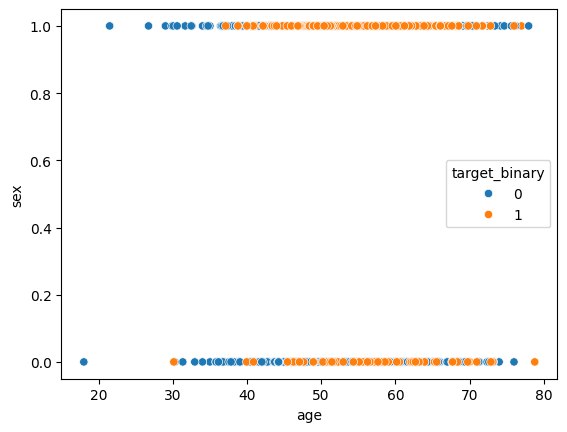

In [9]:
sns.scatterplot(df,x='age',y='sex',hue='target_binary')

<Axes: xlabel='thalach', ylabel='oldpeak'>

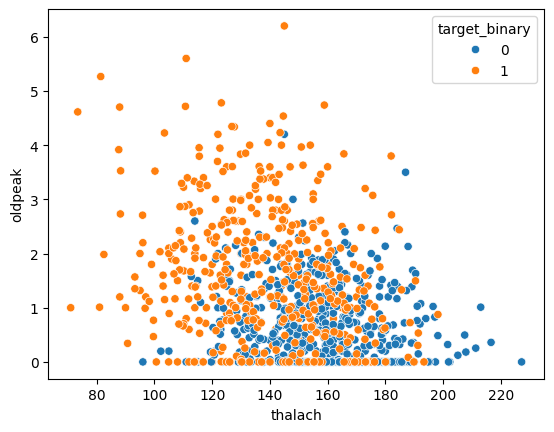

In [10]:
sns.scatterplot(df,x='thalach',y='oldpeak',hue='target_binary')

<Axes: xlabel='age', ylabel='thalach'>

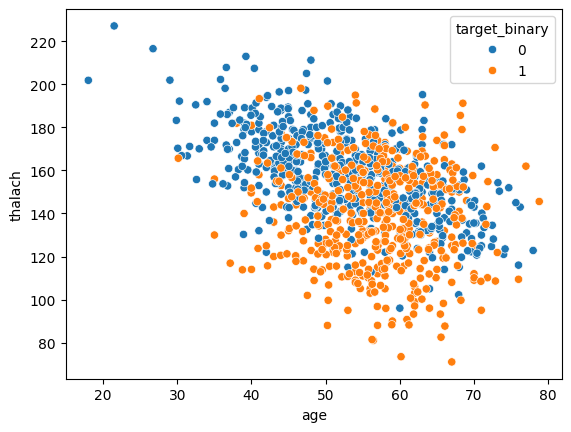

In [11]:
sns.scatterplot(df,x='age',y='thalach',hue='target_binary')

<Axes: xlabel='cp', ylabel='thalach'>

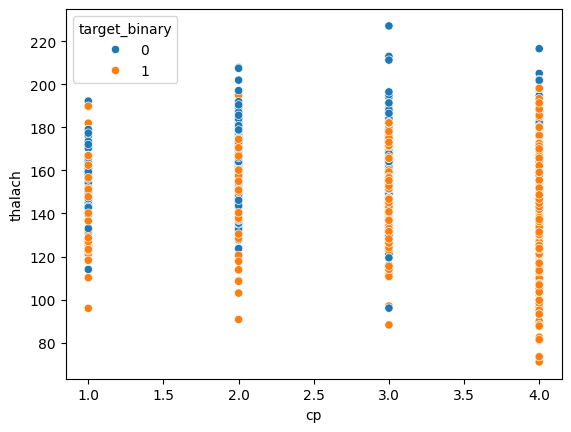

In [12]:
sns.scatterplot(df,x='cp',y='thalach',hue='target_binary')

<Axes: xlabel='oldpeak', ylabel='ca'>

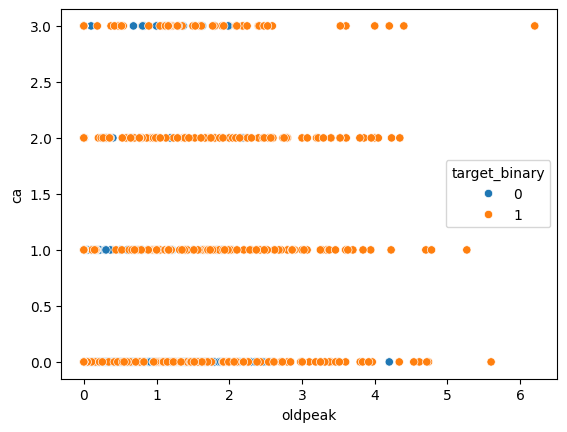

In [13]:
sns.scatterplot(df,x='oldpeak',y='ca',hue='target_binary')

In [14]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
216,46.000000,0,2,105.000000,204.000000,0,0,172.000000,0,0.000000,1,0.0,3.0,0,0
723,61.948071,0,4,160.350037,313.871014,0,2,143.665004,0,2.102279,1,0.0,7.0,2,1
970,65.553190,1,4,144.678634,205.071780,0,0,82.496613,0,1.983255,3,1.0,3.0,2,1
88,53.000000,0,4,138.000000,234.000000,0,2,160.000000,0,0.000000,1,0.0,3.0,0,0
760,51.947683,1,3,138.287472,267.537391,1,0,170.979417,0,1.328772,2,0.0,3.0,2,1


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [16]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('target_binary',axis=1),df['target_binary'],test_size=0.2,random_state=42)

In [17]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [42]:
model=KNeighborsClassifier(n_neighbors=7)
model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [43]:
y_pred=model.predict(x_test)

In [44]:
accuracy_score(y_test,y_pred)

0.9463414634146341

In [21]:
confusion_matrix(y_test,y_pred)

array([[113,   0],
       [ 12,  80]])

In [29]:
# Select only two features
X_train = x_train[:, [2, 9]]
X_test = x_test[:, [2, 9]]

model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train, y_train)

KNeighborsClassifier()

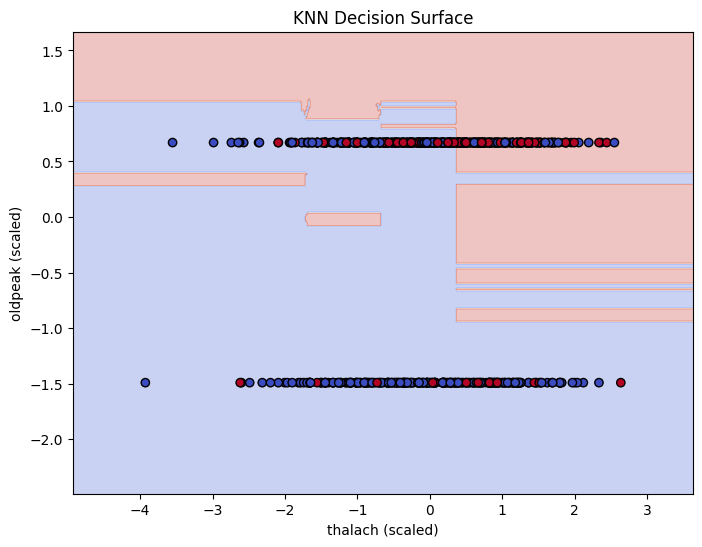

In [30]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c=y_train,
    cmap='coolwarm',
    edgecolors='black'
)

plt.xlabel("thalach (scaled)")
plt.ylabel("oldpeak (scaled)")
plt.title("KNN Decision Surface")
plt.show()

In [31]:
from sklearn.naive_bayes import GaussianNB

In [32]:
nb=GaussianNB()
nb.fit(x_train,y_train)

GaussianNB()

In [33]:
ypred=nb.predict(x_test)

In [34]:
accuracy_score(y_test,ypred)

1.0

In [35]:
confusion_matrix(y_test,ypred)

array([[113,   0],
       [  0,  92]])

In [45]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier()
dc.fit(x_train,y_train)

DecisionTreeClassifier()

In [46]:
y_pred2=dc.predict(x_test)

In [47]:
accuracy_score(y_test,y_pred2)

1.0

In [48]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [49]:
y_pred3=lr.predict(x_test)

In [50]:
accuracy_score(y_test,y_pred3)

0.9951219512195122